In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#!unzip "/content/drive/MyDrive/AI_and_ML/ Week 5 - Introduction to CNN/FruitinAmazon.zip"

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,Model
import numpy as np
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.models import Sequential
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plty
from PIL import Image
from sklearn.metrics import classification_report
import zipfile

zip_path    = '/content/drive/MyDrive/AI_and_ML/ Week 5 - Introduction to CNN/FruitinAmazon.zip'
BASE_DIR = '/content/drive/MyDrive/FruitinAmazon'

if not os.path.exists(BASE_DIR):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(BASE_DIR)
    print(f"Extracted {zip_path} to {BASE_DIR}")
else:
    print(f"Directory {BASE_DIR} already exists, skipping extraction.")

# Adjust BASE_DIR, TRAIN_DIR, and TEST_DIR for nested structure
BASE_DIR = os.path.join(BASE_DIR, 'FruitinAmazon') # Point to the nested folder
TRAIN_DIR= os.path.join(BASE_DIR, "train")
TEST_DIR= os.path.join(BASE_DIR, "test")

print(f"Updated TRAIN_DIR: {TRAIN_DIR}")
print(f"Updated TEST_DIR: {TEST_DIR}")


Directory /content/drive/MyDrive/FruitinAmazon already exists, skipping extraction.
Updated TRAIN_DIR: /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train
Updated TEST_DIR: /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/test


In [ ]:
print(f"Contents of {BASE_DIR}:")
for root, dirs, files in os.walk(BASE_DIR):
    level = root.replace(BASE_DIR, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            print(f'{subindent}{f}')


Contents of /content/drive/MyDrive/FruitinAmazon/FruitinAmazon:
FruitinAmazon/
    test/
        cupuacu/
            download (5).jpeg
            download (3).jpeg
            download (2).jpeg
            images (3).jpeg
            download (4).jpeg
        acai/
            images (2).jpeg
            images (16).jpeg
            images.jpeg
            download (9).jpeg
            images (17).jpeg
        pupunha/
            download (2).jpeg
            download (1).jpeg
            download (11).jpeg
            download (4).jpeg
            download (3).jpeg
        graviola/
            download (1).jpeg
            images (4).jpeg
            download (3).jpeg
            download (2).jpeg
            download (4).jpeg
        tucuma/
            download (1).jpeg
            download (5).jpeg
            download (8).jpeg
            download (4).jpeg
            download (2).jpeg
        guarana/
            download (2).jpeg
            download (4).jpeg
            dow

In [ ]:
class_names = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])
NUM_CLASSES = len(class_names)

if not class_names:
    raise RuntimeError('No class directories found in the train folder!')

print(f"Found {NUM_CLASSES} classes: {class_names}")

# Count images per split
def count_images(directory):
    total = 0
    for cls in os.listdir(directory):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            total += len([f for f in os.listdir(cls_path)
                          if f.lower().endswith(('.jpg','.jpeg','.png'))])
    return total

print(f"Train images : {count_images(TRAIN_DIR)}")
print(f"Test  images : {count_images(TEST_DIR)}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Train images : 90
Test  images : 30


In [ ]:
IMG_SIZE   = (224, 224)   # VGG16 native input size
BATCH_SIZE = 32

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15
)

# Test generator — no augmentation
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nTrain batches      : {len(train_gen)}")
print(f"Validation batches : {len(val_gen)}")
print(f"Test batches       : {len(test_gen)}")

Found 78 images belonging to 6 classes.
Found 12 images belonging to 6 classes.
Found 30 images belonging to 6 classes.

Train batches      : 3
Validation batches : 1
Test batches       : 1


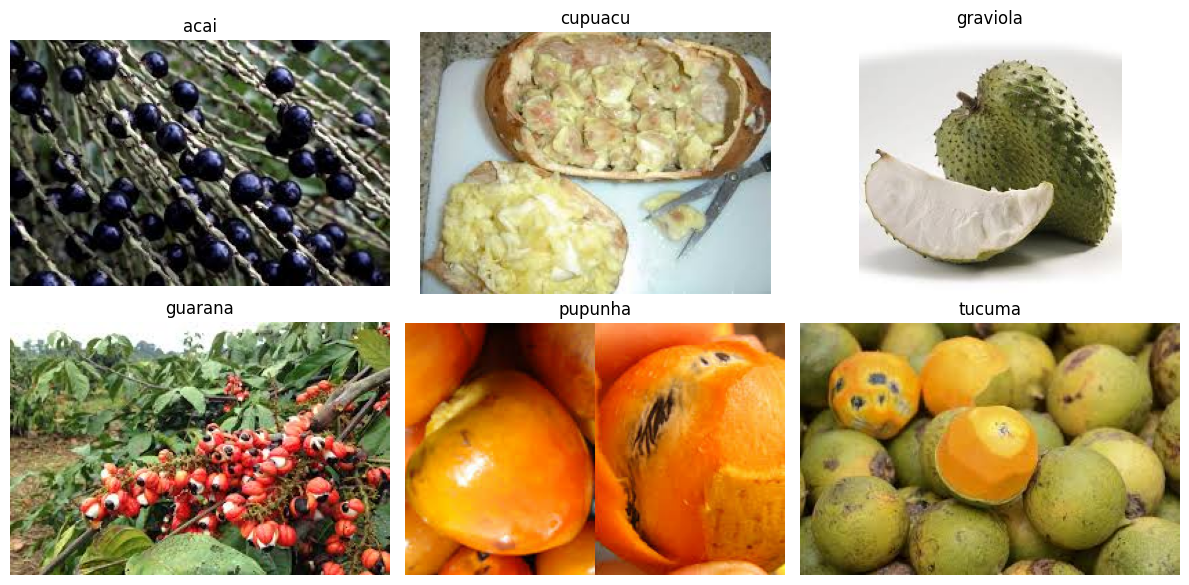

In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
train_dir = TRAIN_DIR # Using the predefined TRAIN_DIR
test_dir = TEST_DIR # Using the predefined TEST_DIR
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images: # Ensure the class folder is not empty
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

In [ ]:
#  Load VGG16 base (no top)
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

# Freeze ALL base layers
base_model.trainable = False

print(f"VGG16 base layers  : {len(base_model.layers)}")
print(f"Trainable params   : {base_model.count_params():,}   all frozen")

#  Custom classification head
inputs  = keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)   # BN layers stay in inference mode
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

feature_model = Model(inputs, outputs, name='VGG16_FeatureExtraction')

#  Compile with Adam
feature_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

feature_model.summary()

VGG16 base layers  : 19
Trainable params   : 14,714,688   all frozen


Model: "VGG16_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,113,286 (57.65 MB)

 Trainable params: 397,062 (1.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [ ]:
EPOCHS_PHASE1 = 20

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_feature_model.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('=' * 55)
print('  PHASE 1 — Feature Extraction Training')
print('=' * 55)

history_phase1 = feature_model.fit(
    train_gen,
    epochs=EPOCHS_PHASE1,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    verbose=1
)

# Evaluate on test set
loss_p1, acc_p1 = feature_model.evaluate(test_gen, verbose=0)
print(f"\n[Phase 1] Test Loss     : {loss_p1:.4f}")
print(f"[Phase 1] Test Accuracy : {acc_p1*100:.2f}%")

  PHASE 1 — Feature Extraction Training
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1011 - loss: 2.9323
Epoch 1: val_accuracy improved from None to 0.50000, saving model to best_feature_model.h5



Epoch 1: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.1538 - loss: 2.6000 - val_accuracy: 0.5000 - val_loss: 2.6336 - learning_rate: 0.0010
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.4477 - loss: 1.5027
Epoch 2: val_accuracy improved from 0.50000 to 0.66667, saving model to best_feature_model.h5



Epoch 2: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 769ms/step - accuracy: 0.5513 - loss: 1.2251 - val_accuracy: 0.6667 - val_loss: 1.6843 - learning_rate: 0.0010
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.6683 - loss: 0.7956
Epoch 3: val_accuracy improved from 0.66667 to 0.75000, saving model to best_feature_model.h5



Epoch 3: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 660ms/step - accuracy: 0.6923 - loss: 0.7288 - val_accuracy: 0.7500 - val_loss: 0.9905 - learning_rate: 0.0010
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.8341 - loss: 0.4348
Epoch 4: val_accuracy improved from 0.75000 to 0.83333, saving model to best_feature_model.h5



Epoch 4: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 640ms/step - accuracy: 0.8462 - loss: 0.4199 - val_accuracy: 0.8333 - val_loss: 0.8292 - learning_rate: 0.0010
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.8860 - loss: 0.2562
Epoch 5: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 700ms/step - accuracy: 0.9231 - loss: 0.2237 - val_accuracy: 0.8333 - val_loss: 0.3274 - learning_rate: 0.0010
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.9037 - loss: 0.3275
Epoch 6: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 774ms/step - accuracy: 0.9231 - loss: 0.2566 - val_accuracy: 0.8333 - val_loss: 0.6428 - learning_rate: 0.0010
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9578 - loss: 0.1405
Epoch 7: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 471ms/step - accuracy: 0.9359 - loss: 0.2041 - val_accuracy: 0.8333 - val_loss: 0.7313 - lear

In [ ]:
#  Rebuild identical architecture
base_model_ft = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

# Freeze all EXCEPT the last convolutional block (block5)
FINE_TUNE_AT = len(base_model_ft.layers) - 2  # unfreeze last 2 layers
for layer in base_model_ft.layers[:FINE_TUNE_AT]:
    layer.trainable = False
for layer in base_model_ft.layers[FINE_TUNE_AT:]:
    layer.trainable = True

trainable_layers = [l.name for l in base_model_ft.layers if l.trainable]
print(f"Unfrozen VGG16 layers: {trainable_layers}")

# Same custom head
inputs  = keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model_ft(inputs, training=True)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

finetune_model = Model(inputs, outputs, name='VGG16_FineTuning')

# Load best weights from Phase 1 into head layers
# (Transfer learned head weights by name matching)
for layer in finetune_model.layers:
    for feat_layer in feature_model.layers:
        if layer.name == feat_layer.name and layer.name != 'vgg16':
            try:
                layer.set_weights(feat_layer.get_weights())
            except:
                pass

# Compile with lower Adam LR
finetune_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),   # 100× lower
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

total_params     = finetune_model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in finetune_model.trainable_weights])
print(f"\nTotal params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
finetune_model.summary()

Unfrozen VGG16 layers: ['block5_conv3', 'block5_pool']

Total params     : 14,879,686
Trainable params : 2,524,806


Model: "VGG16_FineTuning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,686 (56.76 MB)

 Trainable params: 2,524,806 (9.63 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

In [ ]:
EPOCHS_PHASE2 = 100

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_finetune_model.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('=' * 55)
print('  PHASE 2 — Fine-Tuning Training')
print('=' * 55)

history_phase2 = finetune_model.fit(
    train_gen,
    epochs=EPOCHS_PHASE2,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    verbose=1
)

# Evaluate on test set
loss_p2, acc_p2 = finetune_model.evaluate(test_gen, verbose=0)
print(f"\n[Phase 2] Test Loss     : {loss_p2:.4f}")
print(f"[Phase 2] Test Accuracy : {acc_p2*100:.2f}%")
print(f"\n Improvement from Phase 1 → Phase 2: {(acc_p2 - acc_p1)*100:.2f}%")

  PHASE 2 — Fine-Tuning Training
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2366 - loss: 5.3460
Epoch 1: val_accuracy improved from None to 0.41667, saving model to best_finetune_model.h5



Epoch 1: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.2564 - loss: 4.4589 - val_accuracy: 0.4167 - val_loss: 2.1462 - learning_rate: 1.0000e-04
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.4005 - loss: 2.2819
Epoch 2: val_accuracy improved from 0.41667 to 0.58333, saving model to best_finetune_model.h5



Epoch 2: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 560ms/step - accuracy: 0.4359 - loss: 2.1012 - val_accuracy: 0.5833 - val_loss: 1.6369 - learning_rate: 1.0000e-04
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.6584 - loss: 0.9317
Epoch 3: val_accuracy improved from 0.58333 to 0.66667, saving model to best_finetune_model.h5



Epoch 3: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 631ms/step - accuracy: 0.6667 - loss: 0.8350 - val_accuracy: 0.6667 - val_loss: 0.8652 - learning_rate: 1.0000e-04
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.8429 - loss: 0.5262
Epoch 4: val_accuracy improved from 0.66667 to 0.83333, saving model to best_finetune_model.h5



Epoch 4: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 739ms/step - accuracy: 0.8590 - loss: 0.4435 - val_accuracy: 0.8333 - val_loss: 0.7317 - learning_rate: 1.0000e-04
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.9727 - loss: 0.1011
Epoch 5: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 821ms/step - accuracy: 0.9615 - loss: 0.1246 - val_accuracy: 0.7500 - val_loss: 1.0898 - learning_rate: 1.0000e-04
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.9446 - loss: 0.2498
Epoch 6: val_accuracy improved from 0.83333 to 0.91667, saving model to best_finetune_model.h5



Epoch 6: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.9487 - loss: 0.2056 - val_accuracy: 0.9167 - val_loss: 0.6261 - learning_rate: 1.0000e-04
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.9781 - loss: 0.0768
Epoch 7: val_accuracy did not improve from 0.91667
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 864ms/step - accuracy: 0.9872 - loss: 0.0582 - val_accuracy: 0.8333 - val_loss: 0.4101 - learning_rate: 1.0000e-04
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.9561 - loss: 0.0768
Epoch 8: val_accuracy did not improve from 0.91667
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 713ms/step - accuracy: 0.9615 - loss: 0.0648 - val_accuracy: 0.7500 - val_loss: 0.7381 - learning_rate: 1.0000e-04
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.9905 - loss: 0.0352
Epoch 9: val_accuracy did not improve from 0.91667
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 484ms/step - accuracy: 0.9872 - loss: 0.0376 - val_accuracy: 0.8333 - val_loss: 

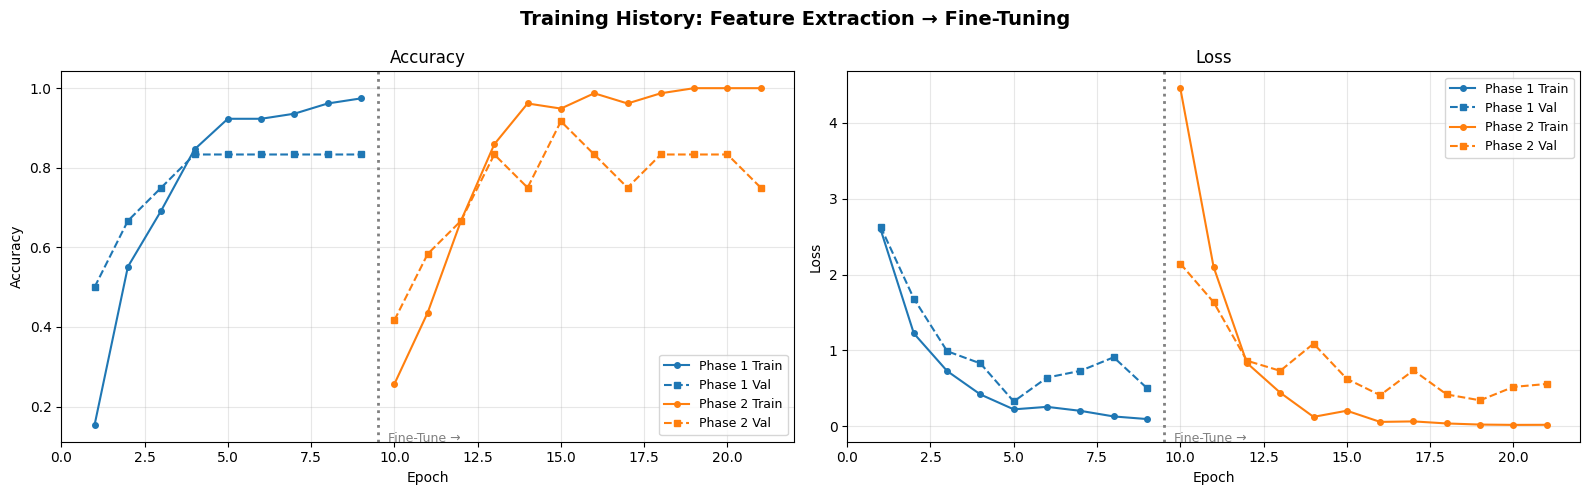

In [ ]:
def plot_combined_history(h1, h2, metric='accuracy'):
    """
    Plot Phase 1 and Phase 2 training curves side-by-side
    with a clear boundary and improvement annotation.
    """
    ep1 = range(1, len(h1.history[metric]) + 1)
    ep2 = range(len(ep1) + 1, len(ep1) + len(h2.history[metric]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Training History: Feature Extraction → Fine-Tuning',
                 fontsize=14, fontweight='bold')

    for ax, met, title in zip(
        axes,
        ['accuracy', 'loss'],
        ['Accuracy', 'Loss']
    ):
        val_met = 'val_' + met

        # Phase 1
        ax.plot(ep1, h1.history[met],     'C0-o', ms=4, label='Phase 1 Train')
        ax.plot(ep1, h1.history[val_met], 'C0--s', ms=4, label='Phase 1 Val')

        # Phase 2
        ax.plot(ep2, h2.history[met],     'C1-o', ms=4, label='Phase 2 Train')
        ax.plot(ep2, h2.history[val_met], 'C1--s', ms=4, label='Phase 2 Val')

        # Boundary
        boundary = len(ep1) + 0.5
        ax.axvline(x=boundary, color='gray', linestyle=':', linewidth=2)
        ax.text(boundary + 0.3, ax.get_ylim()[0], 'Fine-Tune →',
                color='gray', fontsize=9)

        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_combined_history(history_phase1, history_phase2)

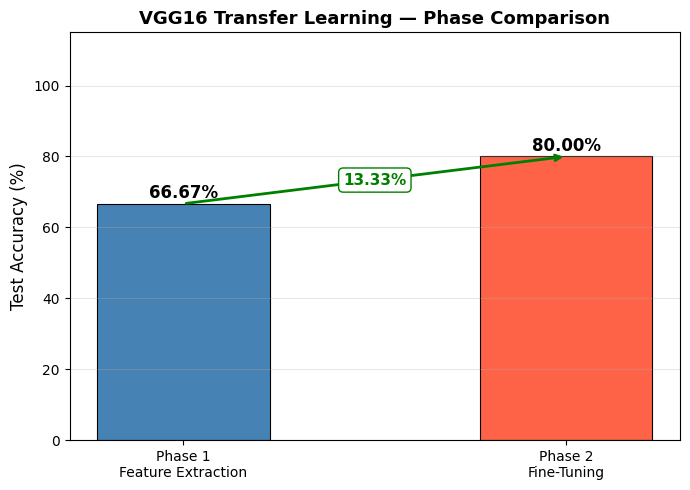

In [ ]:
# ── Bar chart comparing Phase 1 vs Phase 2 ──────────────────
phases  = ['Phase 1\nFeature Extraction', 'Phase 2\nFine-Tuning']
acc_vals = [acc_p1 * 100, acc_p2 * 100]
colors   = ['steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(phases, acc_vals, color=colors, width=0.45, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, acc_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Improvement arrow
ax.annotate('',
            xy=(1, acc_p2 * 100), xytext=(0, acc_p1 * 100),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
mid_y = (acc_p1 + acc_p2) / 2 * 100
ax.text(0.5, mid_y, f'{(acc_p2-acc_p1)*100:.2f}%',
        ha='center', va='center', color='green',
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='green'))

ax.set_ylim(0, 115)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('VGG16 Transfer Learning — Phase Comparison', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
test_gen.reset()
y_pred_prob = finetune_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

print('\n' + '='*55)
print('  Classification Report — Fine-Tuned VGG16')
print('='*55)
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

  Classification Report — Fine-Tuned VGG16
              precision    recall  f1-score   support

        acai     1.0000    0.6000    0.7500         5
     cupuacu     1.0000    1.0000    1.0000         5
    graviola     0.8000    0.8000    0.8000         5
     guarana     1.0000    0.8000    0.8889         5
     pupunha     0.6667    0.8000    0.7273         5
      tucuma     0.5714    0.8000    0.6667         5

    accuracy                         0.8000        30
   macro avg     0.8397    0.8000    0.8055        30
weighted avg     0.8397    0.8000    0.8055        30



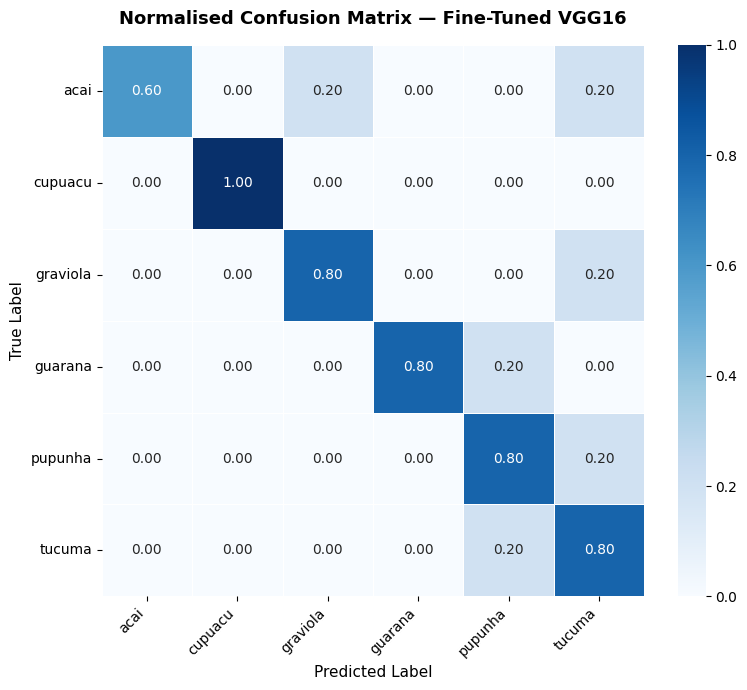

In [ ]:
import seaborn as sns
confmat = confusion_matrix(y_true, y_pred)
confmat_norm = confmat.astype('float') / confmat.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES), max(7, NUM_CLASSES - 1)))
sns.heatmap(
    confmat_norm,
    annot=True, fmt='.2f',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Normalised Confusion Matrix — Fine-Tuned VGG16',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label',      fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

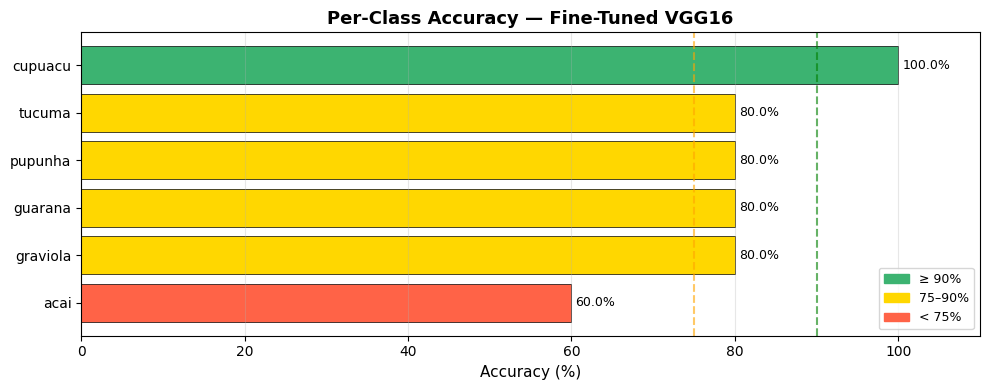

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

per_class_acc = confmat_norm.diagonal()

sorted_idx = np.argsort(per_class_acc)
sorted_classes = [class_names[i] for i in sorted_idx]
sorted_acc     = per_class_acc[sorted_idx]

fig, ax = plt.subplots(figsize=(10, max(4, NUM_CLASSES * 0.45)))
colors_bar = ['tomato' if a < 0.75 else 'gold' if a < 0.90 else 'mediumseagreen'
              for a in sorted_acc]
ax.barh(sorted_classes, sorted_acc * 100, color=colors_bar, edgecolor='black', linewidth=0.5)

for i, (cls, val) in enumerate(zip(sorted_classes, sorted_acc)):
    ax.text(val * 100 + 0.5, i, f'{val*100:.1f}%', va='center', fontsize=9)

ax.axvline(x=90, color='green',  linestyle='--', alpha=0.6, label='90% threshold')
ax.axvline(x=75, color='orange', linestyle='--', alpha=0.6, label='75% threshold')

handles = [
    mpatches.Patch(color='mediumseagreen', label='≥ 90%'),
    mpatches.Patch(color='gold',           label='75–90%'),
    mpatches.Patch(color='tomato',         label='< 75%'),
]
ax.legend(handles=handles, loc='lower right', fontsize=9)

ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Accuracy — Fine-Tuned VGG16', fontsize=13, fontweight='bold')
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()